1. I kapitlet beskrivs en checklista med sju steg. Beskriv de sju stegen översiktligt. I verkligheten, följs dessa steg i en rak progression eller arbetar man generellt sett mer iterativt?
Vi behöver ta reda på vad de e för problem och med vilka verktyg som behövs och som vi ska använda för o lösa det.
Sedan behöver vi hitta källor för data och samla in massor med data.
När vi har datan ska vi analysera den, hitta mönster, avvikelser och viktiga variabler.
Bearbeta datan, göra om texter till siffror osv.
Sedan ska vi träna flera olika enkla modeller och välja dem som presterar bäst.
Efter detta ska lösningen presenteras till folk.
När den blivit godkänd ska vi bygga in och börja använda den.
Man arbetar iterativt, stöter man på problem eller liknande är de vanligt att man går tillbaks från t.ex steg 5 till steg 2.
2.  Vad menas med att en modell produktionssätts?
Att man gör prototypen levande genom att börja använda den i projekt.
3. Vad är scikit-learn för något? Biblioteket följer några centrala designprinciper. Vilka är dessa? Vad är estimators, predictors och transformers?
Scikit learn är standard biblioteket för ML i python.  Estimator: Har Har fit() (huvudklassen, lär sig från data). - Transformer: transform() (modifierar och manipulerar data). - Predictor: Har predict() och score() (förutspår svar). 
4. Vad är TensorFlow och Keras?
Tensorflow är en matematisk motor från Google som primärt inriktar sig på Djupinlärnig. Keras är ett high level api som sitter ovanpå TensorFlow för att utvecklare snabbare ska kunna bygga och koppla ihop lager utan att drunkna i linjär algebra.
5. Kalle och Stina diskuterar maskininlärning över en lunch. Kalle säger: "om jag tränat en modell och den inte presterar bra nog på testdatan så justerar jag den tills den gör det." Stina säger: "det är ett stort fel att göra så, det enda du då åstadkommer är att du överanpassar testdatan. Hela syftet med testdatan försvinner då". Vad säger du om deras dialog?
Stina har rätt, för då overfittar han sin modell och den kmr prestera extremt bra på testdatan visserligen men när den ska köras mot något annat än testdata kommer den prestera extremt dåligt.
6. Många AI/ML-projekt uppnår inte de ursprungligen satta målen eller lyckas ens passera något slags prototypstadie. Vad tror du detta beror på och hur ska vi förhålla oss till det?
Delvis för att man har för lite data eller för dålig data.
Det har inget bra syfte.


In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error
import seaborn as sns



In [14]:
df = pd.read_csv("data_01.csv")

X = df.drop(columns='target')
y = df['target']

In [15]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15)

In [16]:
m1 = LinearRegression().fit(X_train, y_train)
m2 = DecisionTreeRegressor().fit(X_train, y_train)
root_mean_squared_error(y_val, m1.predict(X_val))

error_m1 = root_mean_squared_error(y_val, m1.predict(X_val))
error_m2 = root_mean_squared_error(y_val, m2.predict(X_val))
print(f"Linear Regression RMSE: {error_m1:.2f}")
print(f"Decision Tree RMSE: {error_m2:.2f}")

Linear Regression RMSE: 3.45
Decision Tree RMSE: 74.27


In [17]:
m1.fit(X_train_full, y_train_full)
root_mean_squared_error(y_test, m1.predict(X_test))
m1.fit(X,y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[77.24,87.85,71.77,28.45,31.66]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['x1','x2','x3','x4','x5']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.1269
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [18]:
df = pd.read_csv("salary_dataset.csv")

In [19]:
X = df[['YearsExperience']]
y = df['Salary']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
model = LinearRegression()

result = cross_validate(
    model, 
    X_train, 
    y_train, 
    cv=5, 
    scoring='neg_root_mean_squared_error'
)

In [22]:

mean_rmse = np.mean(-result['test_score'])
print(f"Genomsnittligt valideringsfel (RMSE): {mean_rmse:.2f}")

Genomsnittligt valideringsfel (RMSE): 5293.20


In [ ]:
df = sns.load_dataset("mpg")
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [27]:
df.dropna()
df.drop(columns=['name'])

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,usa
1,15.0,8,350.0,165.0,3693,11.5,70,usa
2,18.0,8,318.0,150.0,3436,11.0,70,usa
3,16.0,8,304.0,150.0,3433,12.0,70,usa
4,17.0,8,302.0,140.0,3449,10.5,70,usa
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa
394,44.0,4,97.0,52.0,2130,24.6,82,europe
395,32.0,4,135.0,84.0,2295,11.6,82,usa
396,28.0,4,120.0,79.0,2625,18.6,82,usa


In [28]:
df = pd.get_dummies(df,columns=['origin'], drop_first=True)

In [29]:
df.info

<bound method DataFrame.info of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year                       name  origin_japan  origin_usa  
0            70  chevrolet cheve

In [ ]:
### KAP 2 REPITION

df = pd.read_csv('data_01.csv')
df.head()

y = df['target']

x = df.drop(columns=['target'])



,x1,x2,x3,x4,x5
0,0.743487,1.072825,1.332911,-1.244771,0.344978
1,0.835264,0.202184,0.966480,0.745883,-0.033773
2,-1.103234,0.030615,-0.140385,0.727683,-2.831224
3,1.210186,1.685258,-0.394123,0.719024,-2.166585
4,0.474577,0.647737,-0.451812,-0.409472,-0.051473


In [35]:
x_train_full, x_test, y_train_full, y_test = train_test_split(x,y,  test_size=0.20, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.15, random_state=42)

In [37]:
reg = LinearRegression().fit(x_train, y_train)
dec = DecisionTreeRegressor().fit(x_train, y_train)

In [41]:
y_pred_reg = reg.predict(x_val)
y_pred_dec = dec.predict(x_val)

error_reg = root_mean_squared_error(y_val, y_pred_reg)
error_dec = root_mean_squared_error(y_val, y_pred_dec)

print(f"RMSE Linear {error_reg:.2f}")
print(f"RMSE Decision {error_dec:.2f}")

RMSE Linear 3.59
RMSE Decision 104.86


In [43]:
final_reg = LinearRegression().fit(x_train_full, y_train_full)

y_pred_reg = final_reg.predict(x_test)

error_reg = root_mean_squared_error(y_test, y_pred_reg)

print(f"RMSE {error_reg:.2f}")

RMSE 3.37


In [ ]:
full_test = LinearRegression().fit(x,y)



RMSE LinearRegression()


In [45]:
df = pd.read_csv("salary_dataset.csv")

In [50]:
df.head()

y = df['Salary']
x = df.drop(columns=['Salary'])

x.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


In [52]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42)

In [57]:
results_reg = cross_validate(LinearRegression(), x_train, y_train, scoring="neg_root_mean_squared_error", cv=5)
results_tree = cross_validate(DecisionTreeRegressor(), x_train, y_train, scoring="neg_root_mean_squared_error", cv=5)

rmse_reg = -results_reg["test_score"].mean()
rmse_tree = -results_tree["test_score"].mean()

print(f"Linear Regression CV RMSE: {rmse_reg:.2f}")
print(f"Decision Tree CV RMSE: {rmse_tree:.2f}")

Linear Regression CV RMSE: 5293.20
Decision Tree CV RMSE: 5611.58


In [58]:
best_model = LinearRegression()
best_model.fit(x_train, y_train)
y_pred_test = best_model.predict(x_test)

test_error = root_mean_squared_error(y_test,y_pred_test)
print(f"Test RMSE: {test_error:.2f}")

Test RMSE: 7059.04


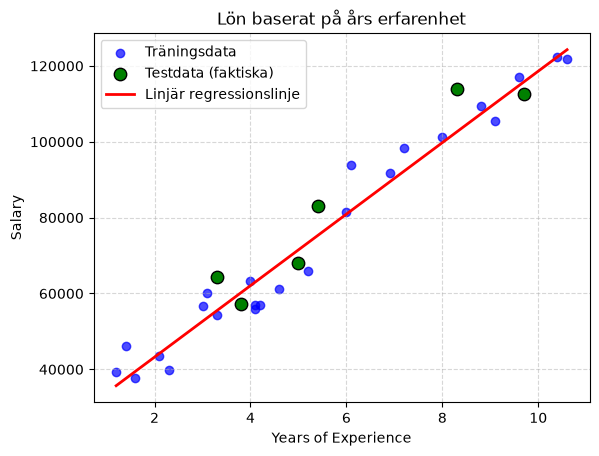

In [59]:
import matplotlib.pyplot as plt

# 1. Plotta datapunkterna
plt.scatter(
    x_train, y_train, color="blue", label="Träningsdata", alpha=0.7
)
plt.scatter(
    x_test,
    y_test,
    color="green",
    s=80,
    label="Testdata (faktiska)",
    edgecolor="black",
)

# 2. Plotta regressionslinjen
# Vi skapar en rak linje över hela x-axeln genom att förutsäga på sorterad data
x_line = x.sort_values(by="YearsExperience")
y_line = best_model.predict(x_line)
plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=2,
    label="Linjär regressionslinje",
)

# 3. Märk upp grafen
plt.title("Lön baserat på års erfarenhet")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# 4. Visa grafen
plt.show()